# Getting Started: VQE for H2

This notebook runs a minimal **VQE** workflow for the hydrogen molecule **H2**.

Goals:

- build and run a simple VQE calculation
- inspect the energy trajectory
- compare the final result with the exact ground-state energy

This is the smallest end-to-end variational workflow in the repository.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe.core import run_vqe
from common.hamiltonian import get_exact_spectrum

## Why H2?

**H2** is the standard small quantum chemistry example:

- very small mapped system
- fast to simulate
- easy to compare against exact diagonalization

It is a good first system for understanding how VQE behaves.

## Run a minimal VQE calculation

We use:

- molecule: `H2`
- ansatz: `UCCSD`
- optimizer: `Adam`
- a small number of optimization steps

The output dictionary contains the final energy, the energy trajectory, and
additional run metadata.

In [2]:
res = run_vqe(
    molecule="H2",
    ansatz_name="UCCSD",
    optimizer_name="Adam",
    steps=50,
    stepsize=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

Step 01/50: E = -1.116684 Ha
Step 02/50: E = -1.136994 Ha
Step 03/50: E = -1.131007 Ha
Step 04/50: E = -1.122700 Ha
Step 05/50: E = -1.130115 Ha
Step 06/50: E = -1.133031 Ha
Step 07/50: E = -1.134496 Ha
Step 08/50: E = -1.134652 Ha
Step 09/50: E = -1.132102 Ha
Step 10/50: E = -1.130839 Ha
Step 11/50: E = -1.133769 Ha
Step 12/50: E = -1.136856 Ha
Step 13/50: E = -1.136817 Ha
Step 14/50: E = -1.134837 Ha
Step 15/50: E = -1.133732 Ha
Step 16/50: E = -1.134458 Ha
Step 17/50: E = -1.135957 Ha
Step 18/50: E = -1.136742 Ha
Step 19/50: E = -1.136508 Ha
Step 20/50: E = -1.136055 Ha
Step 21/50: E = -1.135899 Ha
Step 22/50: E = -1.135938 Ha
Step 23/50: E = -1.136174 Ha
Step 24/50: E = -1.136688 Ha
Step 25/50: E = -1.137068 Ha
Step 26/50: E = -1.136886 Ha
Step 27/50: E = -1.136406 Ha
Step 28/50: E = -1.136270 Ha
Step 29/50: E = -1.136684 Ha
Step 30/50: E = -1.137181 Ha
Step 31/50: E = -1.137213 Ha
Step 32/50: E = -1.136850 Ha
Step 33/50: E = -1.136654 Ha
Step 34/50: E = -1.136858 Ha
Step 35/50: E 

In [3]:
sorted(res.keys())

['energies',
 'energy',
 'final_params',
 'final_state_imag',
 'final_state_real',
 'num_qubits',
 'params_history',
 'steps']

## Final energy

The main quantity of interest is the final variational energy.

In [4]:
final_energy = float(res["energy"])
final_energy

-1.1371763798704708

## Energy trajectory

VQE updates the circuit parameters iteratively. The energy trace shows how the
optimizer moves through the variational landscape.

In [5]:
energies = np.asarray(res["energies"], dtype=float)
energies

array([-1.11668439, -1.11668439, -1.13699403, -1.13100746, -1.1227001 ,
       -1.13011505, -1.13303127, -1.13449588, -1.13465181, -1.13210157,
       -1.13083852, -1.13376913, -1.1368559 , -1.13681672, -1.13483725,
       -1.13373213, -1.13445771, -1.13595669, -1.13674194, -1.1365077 ,
       -1.13605548, -1.13589887, -1.13593842, -1.13617436, -1.13668818,
       -1.13706772, -1.13688597, -1.13640627, -1.13627009, -1.13668371,
       -1.13718097, -1.13721276, -1.1368498 , -1.13665435, -1.1368581 ,
       -1.13713465, -1.13718382, -1.13707536, -1.13700021, -1.13701832,
       -1.13708632, -1.13716268, -1.13720858, -1.13717464, -1.13709669,
       -1.13710243, -1.13720891, -1.13726799, -1.13720734, -1.13714232,
       -1.13717638])

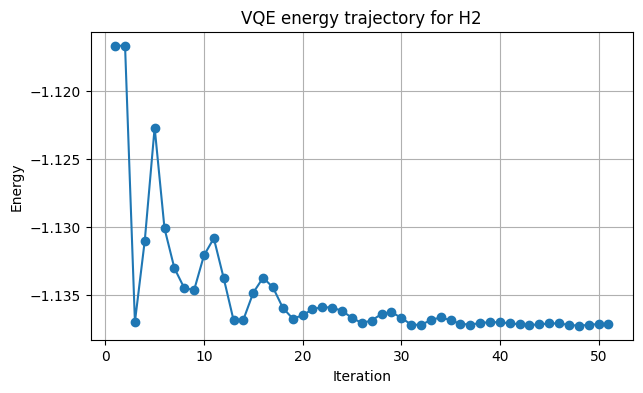

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(energies) + 1), energies, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE energy trajectory for H2")
plt.grid(True)
plt.show()

## Exact reference

For small systems we can compare the VQE result against the exact spectrum.

In [7]:
exact_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])
exact_ground_energy

-1.1372701748841751

In [8]:
abs(final_energy - exact_ground_energy)

9.379501370432308e-05

## Compare VQE and exact ground-state energy

In [9]:
print(f"VQE final energy   : {final_energy:.10f}")
print(f"Exact ground energy: {exact_ground_energy:.10f}")
print(f"Absolute error     : {abs(final_energy - exact_ground_energy):.6e}")

VQE final energy   : -1.1371763799
Exact ground energy: -1.1372701749
Absolute error     : 9.379501e-05


## What this notebook showed

We:

- ran a complete VQE workflow for `H2`
- plotted the optimization trajectory
- compared the variational result to the exact ground-state energy

This is the basic pattern used throughout the repository:

1. choose a molecule
2. run an algorithm
3. inspect convergence
4. compare against a reference where possible